In [1]:
import pandas as pd

In [15]:
file = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/QPy/jsbach_spq/2026_35b_run_transient_slurm_array_mort_hyd_fail_mort_g1/progress.txt"
df_progress = pd.read_csv(file, sep= "\t", parse_dates=['timestamp'])
df_progress['current_step'] = df_progress['progress'].str.split(' ').str[0].astype(int)
df_progress['total_steps'] = df_progress['progress'].str.split(' ').str[-1].astype(int)
df_progress.tail(10)

,timestamp,job,task,progress,rc,duration_s,elapsed_s,rejected,node,current_step,total_steps
3489,2026-02-03 21:13:38,4898146,3475,3490 out of 8192,0,4666.75,29508.39,1,node-r5-he26,3490,8192
3490,2026-02-03 21:13:39,4898220,3511,3491 out of 8192,0,4512.59,29509.73,1,node-r5-he28,3491,8192
3491,2026-02-03 21:13:40,4898152,3476,3492 out of 8192,0,4660.06,29511.36,1,node-r6-he32,3492,8192
3492,2026-02-03 21:13:41,4898257,3534,3493 out of 8192,0,4430.77,29513.06,1,node-r5-he27,3493,8192
3493,2026-02-03 21:13:48,4898164,3482,3494 out of 8192,0,4653.18,29520.86,1,node-r5-he27,3494,8192
3494,2026-02-03 21:13:51,4898110,3453,3495 out of 8192,0,4741.74,29524.25,1,node-r5-he26,3495,8192
3495,2026-02-03 21:13:55,4898107,3451,3496 out of 8192,0,4751.37,29529.21,1,node-r5-he26,3496,8192
3496,2026-02-03 21:13:58,4898219,3510,3497 out of 8192,0,4532.13,29532.67,1,node-r5-he30,3497,8192
3497,2026-02-03 21:14:02,4898192,3493,3498 out of 8192,0,4583.33,29537.37,1,node-r5-he28,3498,8192
3498,2026-02-03 21:14:06,4898074,3437,3499 out of 8192,0,4811.02,29541.69,0,node-r6-he32,3499,8192


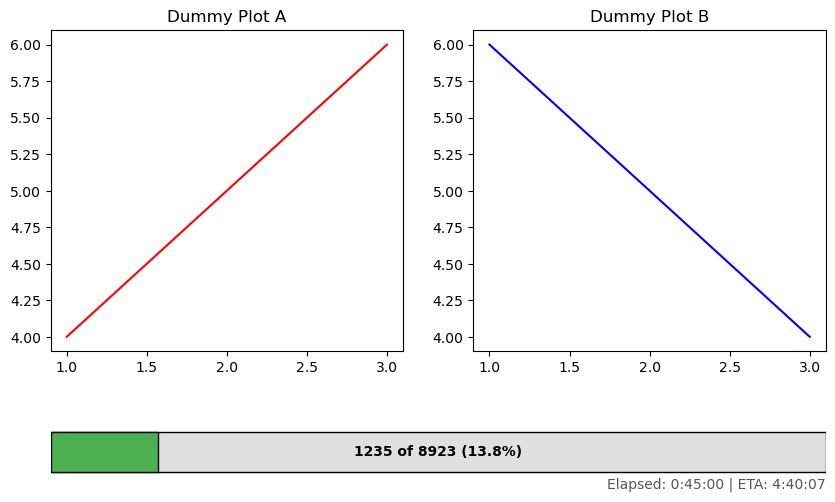

In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import datetime

# --- 1. Setup Simulation Data ---
total_steps = 8923
current_step = 1235
start_time = datetime.datetime.now() - datetime.timedelta(minutes=45) # Dummy start time (45 mins ago)

# --- 2. Calculate Progress & ETA ---
elapsed = datetime.datetime.now() - start_time
elapsed_seconds = elapsed.total_seconds()

# Avoid division by zero
if current_step > 0:
    avg_time_per_step = elapsed_seconds / current_step
    remaining_steps = total_steps - current_step
    eta_seconds = remaining_steps * avg_time_per_step
    eta_str = str(datetime.timedelta(seconds=int(eta_seconds)))
else:
    eta_str = "Calculating..."

pct_complete = (current_step / total_steps) * 100

# --- 3. Create the Layout ---
fig = plt.figure(figsize=(10, 6))

# Define a grid: 2 rows, 2 columns. 
# height_ratios=[4, 1] makes the plots 4x taller than the progress bar
gs = gridspec.GridSpec(2, 2, height_ratios=[4, 1], hspace=0.3)

# Top Row: Two Dummy Plots
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot([1, 2, 3], [4, 5, 6], 'r-')
ax1.set_title("Dummy Plot A")

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot([1, 2, 3], [6, 5, 4], 'b-')
ax2.set_title("Dummy Plot B")

# Bottom Row: The Progress Section (Spans all columns using :)
ax_prog = fig.add_subplot(gs[1, :])

# --- 4. Draw the Progress Bar ---
# Draw background bar (light grey)
ax_prog.barh(0, total_steps, color='#e0e0e0', height=0.5, edgecolor='black')
# Draw progress bar (green)
ax_prog.barh(0, current_step, color='#4caf50', height=0.5, edgecolor='black')

# Clean up the chart to look like a UI
ax_prog.set_xlim(0, total_steps)
ax_prog.set_ylim(-0.5, 0.5)
ax_prog.set_xticks([]) # Remove numbers on x-axis
ax_prog.set_yticks([]) # Remove numbers on y-axis
ax_prog.spines['top'].set_visible(False)
ax_prog.spines['right'].set_visible(False)
ax_prog.spines['bottom'].set_visible(False)
ax_prog.spines['left'].set_visible(False)

# --- 5. Add Text Stats ---
# Center text
ax_prog.text(total_steps/2, 0, f"{current_step} of {total_steps} ({pct_complete:.1f}%)", 
             ha='center', va='center', fontweight='bold', color='black')

# ETA Text (Bottom Right corner of the bar area)
ax_prog.text(total_steps, -0.4, f"Elapsed: {str(elapsed).split('.')[0]} | ETA: {eta_str}", 
             ha='right', va='center', fontsize=10, color='#555')

plt.show()

/tmp/ipykernel_212827/3637441570.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


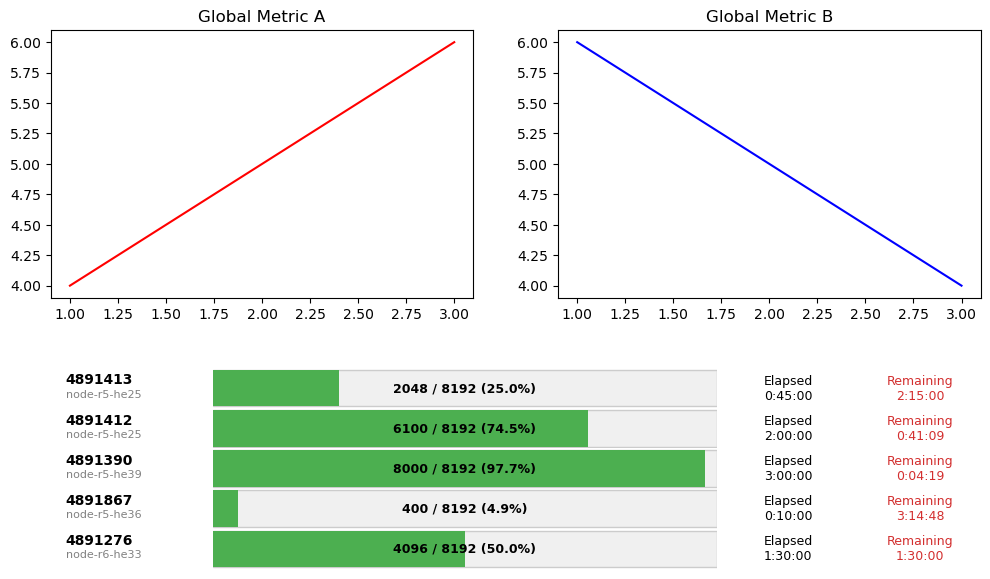

In [21]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import datetime

# --- 1. Setup Dummy Data for Multiple Jobs ---
# In a real scenario, this list would come from your parsed file/dataframe
jobs_data = [
    {"id": "4891413", "node": "node-r5-he25", "total": 8192, "current": 2048, "start_min_ago": 45},
    {"id": "4891412", "node": "node-r5-he25", "total": 8192, "current": 6100, "start_min_ago": 120},
    {"id": "4891390", "node": "node-r5-he39", "total": 8192, "current": 8000, "start_min_ago": 180},
    {"id": "4891867", "node": "node-r5-he36", "total": 8192, "current": 400, "start_min_ago": 10},
    {"id": "4891276", "node": "node-r6-he33", "total": 8192, "current": 4096, "start_min_ago": 90},
]

num_jobs = len(jobs_data)

# --- 2. Define Layout Dimensions ---
# We calculate figure height dynamically so it grows if you add more jobs
# Base height (plots) + (Height per job row * num_jobs)
row_height_per_job = 0.6
header_height = 4.0 
fig_height = header_height + (num_jobs * row_height_per_job)

fig = plt.figure(figsize=(12, fig_height))

# Main Split: Top (Plots) vs Bottom (Job List)
# We set the height ratio so the bottom part grows exactly as needed
gs_main = gridspec.GridSpec(2, 1, height_ratios=[header_height, num_jobs * row_height_per_job], hspace=0.3)

# ==========================================
# PART A: THE PLOTS (Top Section)
# ==========================================
gs_plots = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[0], wspace=0.2)

ax1 = fig.add_subplot(gs_plots[0])
ax1.plot([1, 2, 3], [4, 5, 6], 'r-')
ax1.set_title("Global Metric A")

ax2 = fig.add_subplot(gs_plots[1])
ax2.plot([1, 2, 3], [6, 5, 4], 'b-')
ax2.set_title("Global Metric B")

# ==========================================
# PART B: THE JOB ROWS (Bottom Section)
# ==========================================
# Create a sub-grid with 'num_jobs' rows
gs_jobs = gridspec.GridSpecFromSubplotSpec(num_jobs, 1, subplot_spec=gs_main[1], hspace=0.0)

for i, job in enumerate(jobs_data):
    # 1. Calc Stats
    pct = (job["current"] / job["total"]) * 100
    # Simulate time calc
    elapsed_sec = job["start_min_ago"] * 60
    if job["current"] > 0:
        total_est_sec = (elapsed_sec / job["current"]) * job["total"]
        rem_sec = total_est_sec - elapsed_sec
        eta_str = str(datetime.timedelta(seconds=int(rem_sec)))
    else:
        eta_str = "--:--:--"
    
    elapsed_str = str(datetime.timedelta(seconds=int(elapsed_sec)))

    # 2. Create the Row Layout (4 Columns: ID | Progress | Elapsed | Remaining)
    # This creates a nested grid for THIS specific row
    gs_row = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs_jobs[i], 
                                              width_ratios=[1.5, 5, 1.2, 1.2], wspace=0.05)
    
    # --- Col 1: Job ID ---
    ax_id = fig.add_subplot(gs_row[0])
    ax_id.axis('off')
    # Bold the ID, lighter text for the node
    ax_id.text(0.1, 0.5, f"{job['id']}\n", fontweight='bold', ha='left', va='center', fontsize=10)
    ax_id.text(0.1, 0.35, f"{job['node']}", color='gray', ha='left', va='center', fontsize=8)

    # --- Col 2: Progress Bar ---
    ax_prog = fig.add_subplot(gs_row[1])
    ax_prog.axis('off')
    # Background bar
    ax_prog.barh(0, job["total"], color='#f0f0f0', height=0.6, edgecolor='#cccccc')
    # Fill bar (Color changes based on progress!)
    bar_color = '#4caf50' if pct < 100 else '#2196f3' # Green if running, Blue if done
    ax_prog.barh(0, job["current"], color=bar_color, height=0.6)
    ax_prog.set_xlim(0, job["total"])
    # Text overlay
    ax_prog.text(0.5, 0.5, f"{job['current']} / {job['total']} ({pct:.1f}%)", 
                 ha='center', va='center', fontsize=9, fontweight='bold', transform=ax_prog.transAxes)

    # --- Col 3: Elapsed ---
    ax_el = fig.add_subplot(gs_row[2])
    ax_el.axis('off')
    ax_el.text(0.5, 0.5, f"Elapsed\n{elapsed_str}", ha='center', va='center', fontsize=9)

    # --- Col 4: Remaining ---
    ax_rem = fig.add_subplot(gs_row[3])
    ax_rem.axis('off')
    ax_rem.text(0.5, 0.5, f"Remaining\n{eta_str}", ha='center', va='center', fontsize=9, color='#d32f2f')

plt.tight_layout()
plt.show()

/tmp/ipykernel_212827/3426225001.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


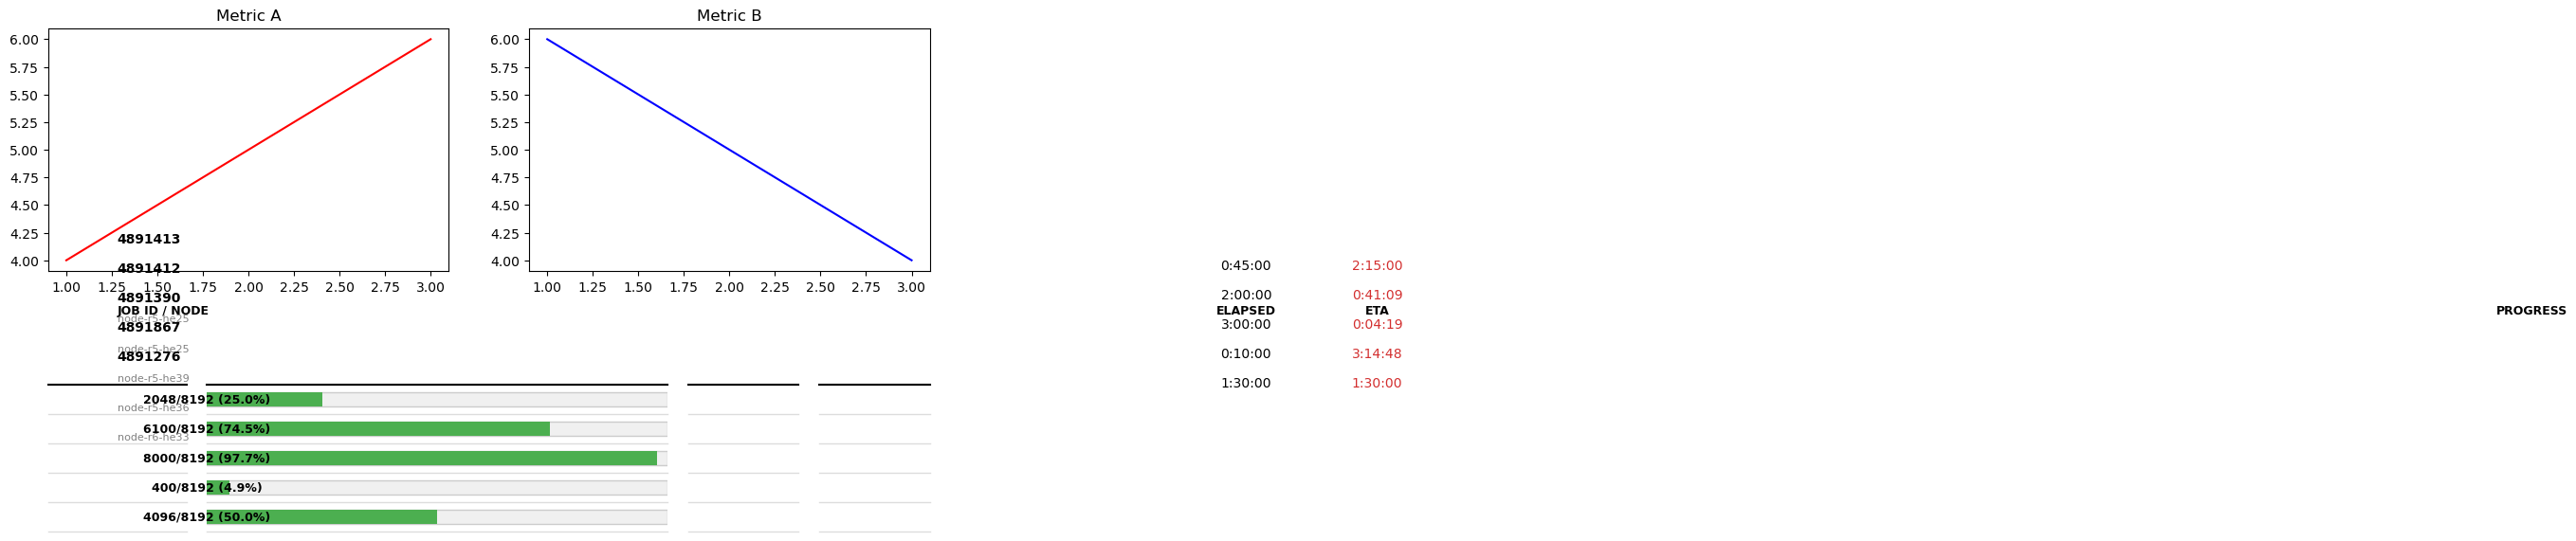

In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import datetime

# --- 1. Setup Dummy Data ---
jobs_data = [
    {"id": "4891413", "node": "node-r5-he25", "total": 8192, "current": 2048, "start_min_ago": 45},
    {"id": "4891412", "node": "node-r5-he25", "total": 8192, "current": 6100, "start_min_ago": 120},
    {"id": "4891390", "node": "node-r5-he39", "total": 8192, "current": 8000, "start_min_ago": 180},
    {"id": "4891867", "node": "node-r5-he36", "total": 8192, "current": 400, "start_min_ago": 10},
    {"id": "4891276", "node": "node-r6-he33", "total": 8192, "current": 4096, "start_min_ago": 90},
]

num_jobs = len(jobs_data)

# --- 2. Layout Dimensions ---
# Header Row height + (Job Rows * Height per row)
# We add +1 to num_jobs to account for the table header
row_height = 0.5
table_header_height = 0.4
plots_height = 4.0

fig_height = plots_height + table_header_height + (num_jobs * row_height)
fig = plt.figure(figsize=(12, fig_height))

# Main Split: Top (Plots) vs Bottom (Table)
gs_main = gridspec.GridSpec(2, 1, 
                            height_ratios=[plots_height, table_header_height + (num_jobs * row_height)], 
                            hspace=0.4)

# ==========================================
# PART A: PLOTS
# ==========================================
gs_plots = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[0], wspace=0.2)

ax1 = fig.add_subplot(gs_plots[0])
ax1.plot([1, 2, 3], [4, 5, 6], 'r-')
ax1.set_title("Metric A")

ax2 = fig.add_subplot(gs_plots[1])
ax2.plot([1, 2, 3], [6, 5, 4], 'b-')
ax2.set_title("Metric B")

# ==========================================
# PART B: THE TABLE
# ==========================================
# We create a Grid with (num_jobs + 1) rows and 4 columns
# Columns: ID | Progress Bar | Elapsed | ETA
cols_width_ratios = [1.5, 5, 1.2, 1.2]
gs_table = gridspec.GridSpecFromSubplotSpec(num_jobs + 1, 4, 
                                            subplot_spec=gs_main[1], 
                                            width_ratios=cols_width_ratios, 
                                            hspace=0.0, wspace=0.1)

# --- Helper to draw lines ---
def format_cell(ax, is_header=False):
    ax.axis('off')
    # Draw a line at the bottom of the cell
    ax.plot([0, 1], [0, 0], color='#dddddd', transform=ax.transAxes, linewidth=1, clip_on=False)
    if is_header:
        # Thicker line for header
        ax.plot([0, 1], [0, 0], color='black', transform=ax.transAxes, linewidth=1.5, clip_on=False)

# --- 1. Draw Header Row (Row 0) ---
headers = ["JOB ID / NODE", "PROGRESS", "ELAPSED", "ETA"]
for col_idx, text in enumerate(headers):
    ax_h = fig.add_subplot(gs_table[0, col_idx])
    format_cell(ax_h, is_header=True)
    # Align text: Left for ID, Center for others
    align = 'left' if col_idx == 0 else 'center'
    # Shift x slightly if left aligned
    x_pos = 0.0 if align == 'left' else 0.5
    ax_h.text(x_pos, 0.2, text, fontweight='bold', fontsize=9, ha=align, va='bottom')

# --- 2. Draw Data Rows (Row 1 to N) ---
for i, job in enumerate(jobs_data):
    row_idx = i + 1  # Offset by 1 because of header
    
    # Calc Stats
    pct = (job["current"] / job["total"]) * 100
    elapsed_sec = job["start_min_ago"] * 60
    if job["current"] > 0:
        rem_sec = ((elapsed_sec / job["current"]) * job["total"]) - elapsed_sec
        eta_str = str(datetime.timedelta(seconds=int(rem_sec)))
    else:
        eta_str = "--:--:--"
    elapsed_str = str(datetime.timedelta(seconds=int(elapsed_sec)))

    # -- Col 1: Job ID --
    ax_id = fig.add_subplot(gs_table[row_idx, 0])
    format_cell(ax_id)
    ax_id.text(0, 0.6, job['id'], fontweight='bold', ha='left', va='center', fontsize=10)
    ax_id.text(0, 0.3, job['node'], color='gray', ha='left', va='center', fontsize=8)

    # -- Col 2: Progress Bar --
    ax_bar = fig.add_subplot(gs_table[row_idx, 1])
    format_cell(ax_bar)
    # Background
    ax_bar.barh(0.5, job["total"], color='#f0f0f0', height=0.5, edgecolor='#cccccc', align='center')
    # Fill
    color = '#4caf50' if pct < 100 else '#2196f3'
    ax_bar.barh(0.5, job["current"], color=color, height=0.5, align='center')
    ax_bar.set_ylim(0, 1)
    ax_bar.set_xlim(0, job["total"])
    # Text Overlay
    ax_bar.text(0.5, 0.5, f"{job['current']}/{job['total']} ({pct:.1f}%)", 
                ha='center', va='center', fontsize=9, fontweight='bold')

    # -- Col 3: Elapsed --
    ax_el = fig.add_subplot(gs_table[row_idx, 2])
    format_cell(ax_el)
    ax_el.text(0.5, 0.5, elapsed_str, ha='center', va='center', fontsize=10)

    # -- Col 4: ETA --
    ax_eta = fig.add_subplot(gs_table[row_idx, 3])
    format_cell(ax_eta)
    ax_eta.text(0.5, 0.5, eta_str, ha='center', va='center', fontsize=10, color='#d32f2f')

plt.tight_layout()
plt.show()